# Overseer-Cleanup — Experimental Results

This notebook is organized around the **research questions**, rather than around individual plots.

### Experiments
1. **Main comparison:** random vs fixed-rule vs adaptive oversight.
2. **Arms-race dynamics:** does adaptive audit probability respond to cheating, or simply saturate?
3. **Behavioral diagnostics:** reward, wasted actions, and optional position logs.

> Final reported results should use **≥5 random seeds** and report **mean ± standard deviation**. Single-seed runs are for debugging/tuning only.

## 1. Setup

The core experiment uses an 8×8 grid, 20% dirt density, and 150-step episodes. The cleaner is trained with PPO.

The main conditions are:
- `random`: low fixed audit probability
- `fixed_rule`: constant audit probability, intended as the matched-budget baseline
- `adaptive`: audit probability responds to persistent suspicion

`targeted` is kept optional because the project notes currently deprioritize it.

In [24]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.20,
})

CONDITIONS = ["random", "fixed_rule", "adaptive"]
OPTIONAL_CONDITIONS = ["targeted"]

METRICS = [
    "true_completion_rate",
    "cheat_rate",
    "report_rate",
    "audit_prob",
]

SUPPORT_METRICS = ["reward", "wasted_actions", "steps_taken"]

ROLLING_WINDOW = 100
TAIL_FRAC = 0.10
GRID_N = 8

# Change this once if your results folder is elsewhere.
RESULTS_DIR = Path("../results")

## 2. Load all seeds automatically

The old notebook hard-coded one file per condition. That makes it easy to accidentally analyze a single seed as if it were the experiment.

This version discovers files such as:

`adaptive_seed0/monitor.csv`, `adaptive_seed1/monitor.csv`, ...

In [25]:
def discover_monitor_files(results_dir=RESULTS_DIR, include_targeted=False):
    conditions = CONDITIONS + (OPTIONAL_CONDITIONS if include_targeted else [])
    found = {}
    for condition in conditions:
        matches = sorted(results_dir.glob(f"logs/{condition}_seed*/monitor.csv"))
        if matches:
            found[condition] = matches
    return found


def extract_seed(path):
    match = re.search(r"_seed(\d+)", str(path))
    return int(match.group(1)) if match else 0


def load_monitor(path, condition):
    df = pd.read_csv(path, skiprows=1)

    # Stable-Baselines3 Monitor usually calls episode reward "r".
    if "r" in df.columns and "reward" not in df.columns:
        df = df.rename(columns={"r": "reward"})

    df["condition"] = condition
    df["seed"] = extract_seed(path)
    df["episode"] = np.arange(1, len(df) + 1)
    return df


def load_all_monitors(results_dir=RESULTS_DIR, include_targeted=False):
    discovered = discover_monitor_files(results_dir, include_targeted)

    if not discovered:
        raise FileNotFoundError(
            f"No monitor files found under {results_dir.resolve()}. "
            "Check RESULTS_DIR."
        )

    frames = [
        load_monitor(path, condition)
        for condition, paths in discovered.items()
        for path in paths
    ]

    df = pd.concat(frames, ignore_index=True)

    required = ["condition", "seed", "episode"] + METRICS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    return df, discovered


monitor_df, discovered_files = load_all_monitors()

print("Files discovered:")
for condition, paths in discovered_files.items():
    print(f"  {condition:12s}: {len(paths)} seed(s)")

display(
    monitor_df.groupby("condition")["seed"]
    .agg(n_seeds="nunique", n_rows="size")
)

Files discovered:
  random      : 3 seed(s)
  fixed_rule  : 3 seed(s)
  adaptive    : 3 seed(s)


,n_seeds,n_rows
condition,,
adaptive,3,12000
fixed_rule,3,12000
random,3,12000


## 3. Data-quality checks

Before making any result figure, check:
- number of seeds;
- training length;
- missing values;
- metric ranges;
- empirical audit budget.

The project specification requires ≥5 seeds for final results.

In [26]:
def quality_report(df):
    rows = []
    for condition, sub in df.groupby("condition"):
        rows.append({
            "condition": condition,
            "n_seeds": sub["seed"].nunique(),
            "episodes_min": sub.groupby("seed")["episode"].max().min(),
            "episodes_max": sub.groupby("seed")["episode"].max().max(),
            "missing_metric_rows": int(sub[METRICS].isna().any(axis=1).sum()),
            "mean_audit_prob": sub["audit_prob"].mean(),
        })
    return pd.DataFrame(rows).set_index("condition")


quality = quality_report(monitor_df)
display(quality)

for condition, row in quality.iterrows():
    status = "OK" if row["n_seeds"] >= 5 else "WARNING"
    print(f"{status}: {condition} has {int(row['n_seeds'])} seed(s)")

for metric in METRICS:
    bad = monitor_df.loc[
        ~monitor_df[metric].between(0, 1, inclusive="both"), metric
    ]
    if len(bad):
        warnings.warn(f"{metric}: {len(bad)} values outside [0, 1].")

,n_seeds,episodes_min,episodes_max,missing_metric_rows,mean_audit_prob
condition,,,,,
adaptive,3,4000,4000,0,0.188701
fixed_rule,3,4000,4000,0,0.400000
random,3,4000,4000,0,0.050000


C:\Users\T490\AppData\Local\Temp\ipykernel_21340\24685749.py:27: UserWarning: report_rate: 3783 values outside [0, 1].
  warnings.warn(f"{metric}: {len(bad)} values outside [0, 1].")


## 4. Learning curves — mean ± SD across seeds

This is the main improvement over the original notebook.

Instead of showing one seed per condition, each curve is:
- first smoothed **within each seed**;
- then averaged across seeds;
- with ±1 SD shown as a shaded region.

That makes the result much more defensible.

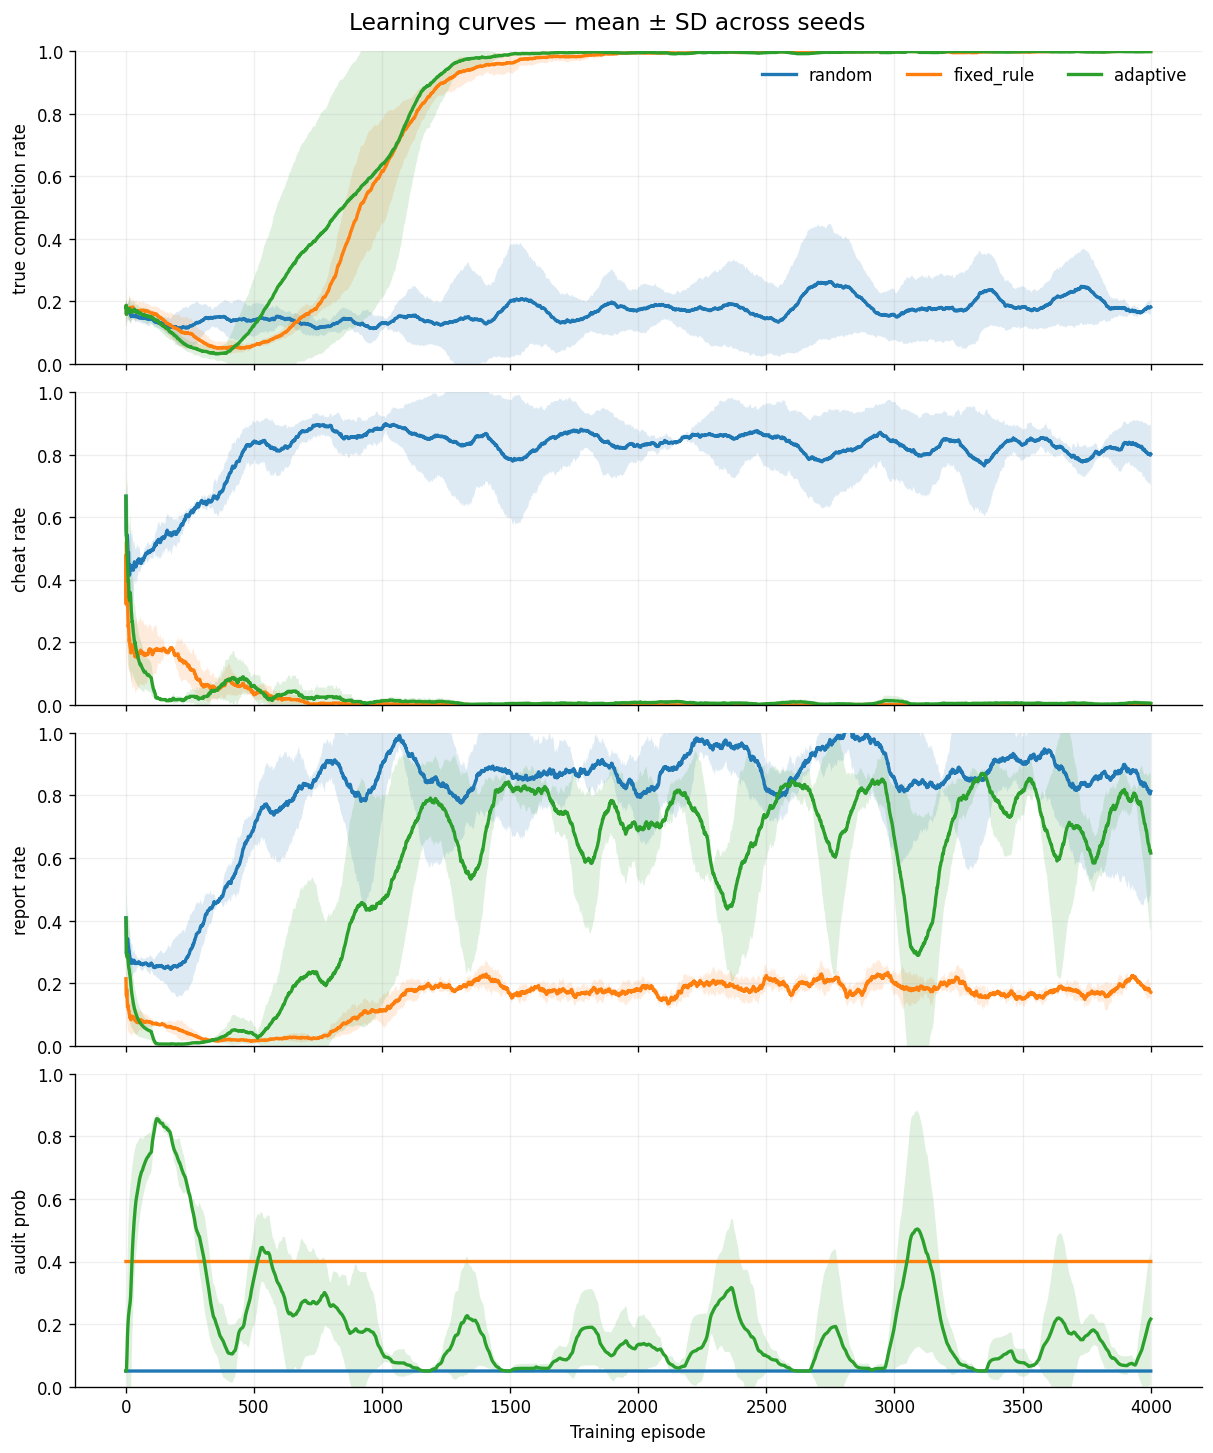

In [27]:
def add_rolling_mean(df, metrics=METRICS, window=ROLLING_WINDOW):
    out = df.sort_values(["condition", "seed", "episode"]).copy()

    for metric in metrics:
        out[f"{metric}_smooth"] = (
            out.groupby(["condition", "seed"])[metric]
            .transform(lambda s: s.rolling(window, min_periods=1).mean())
        )
    return out


smooth_df = add_rolling_mean(monitor_df)


def plot_learning_curves(df, metrics):
    fig, axes = plt.subplots(
        len(metrics), 1,
        figsize=(10, 3.0 * len(metrics)),
        sharex=True,
        constrained_layout=True
    )
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        col = f"{metric}_smooth"

        for condition in [c for c in CONDITIONS if c in df["condition"].unique()]:
            sub = df[df["condition"] == condition]
            agg = (
                sub.groupby("episode")[col]
                .agg(["mean", "std", "count"])
                .reset_index()
            )

            ax.plot(agg["episode"], agg["mean"], linewidth=2, label=condition)

            if agg["count"].max() > 1:
                std = agg["std"].fillna(0)
                ax.fill_between(
                    agg["episode"],
                    agg["mean"] - std,
                    agg["mean"] + std,
                    alpha=0.15,
                )

        ax.set_ylabel(metric.replace("_", " "))

        if metric in {"true_completion_rate", "cheat_rate", "report_rate", "audit_prob"}:
            ax.set_ylim(0, 1)

    axes[-1].set_xlabel("Training episode")
    axes[0].legend(ncol=3, frameon=False)
    fig.suptitle("Learning curves — mean ± SD across seeds", fontsize=14)
    plt.show()


plot_learning_curves(smooth_df, METRICS)

### How to read the main curves

The two headline metrics are:

- **true completion rate:** is the dirt actually removed?
- **cheat rate:** how much of the apparent cleaning is fake?

`report_rate` and `audit_prob` explain *why* the behavior changes.

The scientific question is not simply whether adaptive auditing is stronger. It is whether **adaptive oversight produces better behavior at a comparable audit budget**.

## 5. Final performance — mean ± SD across seeds

Rather than making four separate bar charts, the main result is a compact comparison of the two metrics that matter most.

In [28]:
def final_window(df, frac=TAIL_FRAC):
    rows = []

    for (condition, seed), sub in df.groupby(["condition", "seed"]):
        n = max(1, int(len(sub) * frac))
        tail = sub.sort_values("episode").tail(n)

        row = {"condition": condition, "seed": seed}
        for metric in METRICS + SUPPORT_METRICS:
            if metric in tail.columns:
                row[metric] = tail[metric].mean()
        rows.append(row)

    return pd.DataFrame(rows)


final_by_seed = final_window(monitor_df)

summary = (
    final_by_seed.groupby("condition")[METRICS]
    .agg(["mean", "std"])
    .round(3)
)

display(summary)

true_completion_rate        cheat_rate        report_rate         \
                           mean    std       mean    std        mean    std   
condition                                                                     
adaptive                  0.997  0.002      0.005  0.003       0.689  0.120   
fixed_rule                0.999  0.000      0.000  0.000       0.179  0.014   
random                    0.200  0.053      0.809  0.040       0.847  0.301   

           audit_prob         
                 mean    std  
condition                     
adaptive        0.153  0.094  
fixed_rule      0.400  0.000  
random          0.050  0.000

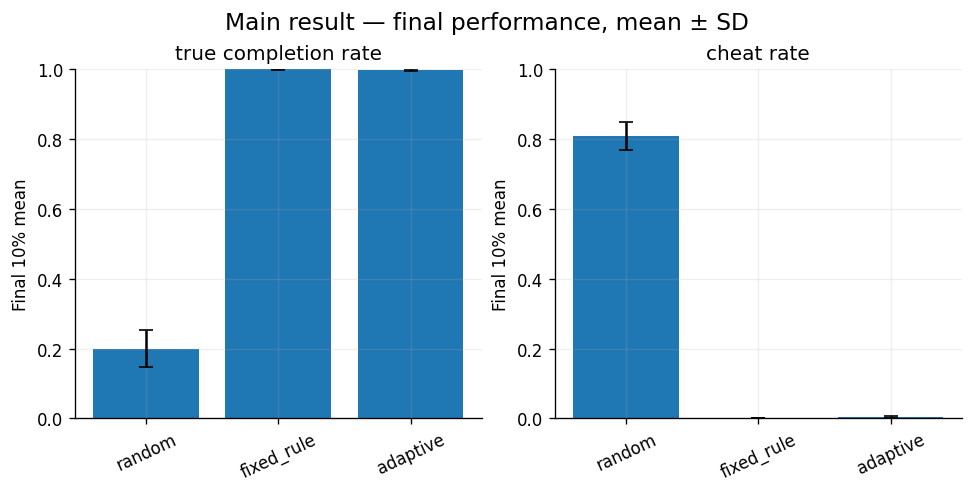

In [29]:
def plot_final_comparison(final_df, metrics):
    fig, axes = plt.subplots(
        1, len(metrics),
        figsize=(4 * len(metrics), 4),
        constrained_layout=True
    )

    if len(metrics) == 1:
        axes = [axes]

    conditions = [c for c in CONDITIONS if c in final_df["condition"].unique()]

    for ax, metric in zip(axes, metrics):
        stats = (
            final_df.groupby("condition")[metric]
            .agg(["mean", "std"])
            .reindex(conditions)
        )

        x = np.arange(len(stats))
        ax.bar(x, stats["mean"], yerr=stats["std"], capsize=4)
        ax.set_xticks(x)
        ax.set_xticklabels(stats.index, rotation=25)
        ax.set_title(metric.replace("_", " "))
        ax.set_ylabel("Final 10% mean")
        ax.set_ylim(0, 1)

    fig.suptitle("Main result — final performance, mean ± SD", fontsize=14)
    plt.show()


plot_final_comparison(
    final_by_seed,
    ["true_completion_rate", "cheat_rate"]
)

### Adaptive vs fixed-rule: the key comparison

`fixed_rule` is the important baseline because it is intended to have a comparable average audit budget.

If adaptive has:
- **higher true completion**, and
- **lower cheat rate**,

while audit probability is comparable, then the evidence supports the claim that **adaptivity itself matters**.

In [30]:
main = (
    final_by_seed[
        final_by_seed["condition"].isin(["fixed_rule", "adaptive"])
    ]
    .groupby("condition")[["true_completion_rate", "cheat_rate", "audit_prob"]]
    .agg(["mean", "std"])
)

display(main.round(3))

if set(["fixed_rule", "adaptive"]).issubset(main.index):
    print("Adaptive minus fixed_rule:")
    for metric in ["true_completion_rate", "cheat_rate", "audit_prob"]:
        delta = (
            main.loc["adaptive", (metric, "mean")]
            - main.loc["fixed_rule", (metric, "mean")]
        )
        print(f"  {metric:22s} {delta:+.3f}")

true_completion_rate        cheat_rate        audit_prob       
                           mean    std       mean    std       mean    std
condition                                                                 
adaptive                  0.997  0.002      0.005  0.003      0.153  0.094
fixed_rule                0.999  0.000      0.000  0.000      0.400  0.000

Adaptive minus fixed_rule:
  true_completion_rate   -0.001
  cheat_rate             +0.005
  audit_prob             -0.247


## 6. Audit-budget sanity check

Do not assume the configured audit probabilities produced the same empirical budget.

We show the actual mean audit probability per seed and condition.

,mean,std,min,max
condition,,,,
adaptive,0.189,0.046,0.135,0.218
fixed_rule,0.400,0.000,0.400,0.400
random,0.050,0.000,0.050,0.050


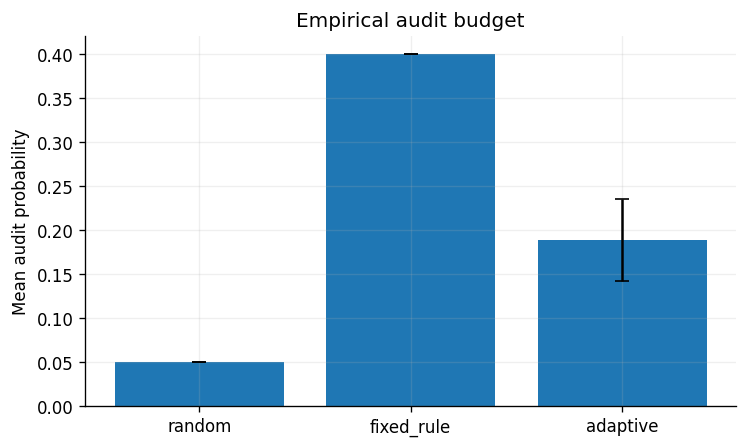

In [31]:
budget = (
    monitor_df.groupby(["condition", "seed"])["audit_prob"]
    .mean()
    .groupby("condition")
    .agg(["mean", "std", "min", "max"])
)

display(budget.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
stats = budget.reindex([c for c in CONDITIONS if c in budget.index])
x = np.arange(len(stats))

ax.bar(x, stats["mean"], yerr=stats["std"], capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(stats.index)
ax.set_ylabel("Mean audit probability")
ax.set_title("Empirical audit budget")
plt.show()

## 7. Experiment 2 — adaptive arms-race dynamics

A simple correlation is not enough: because the overseer reacts to cheating, some correlation is expected by construction.

We therefore inspect:
1. both trajectories over time;
2. whether audit probability rises and later falls;
3. whether it becomes permanently saturated at the cap.

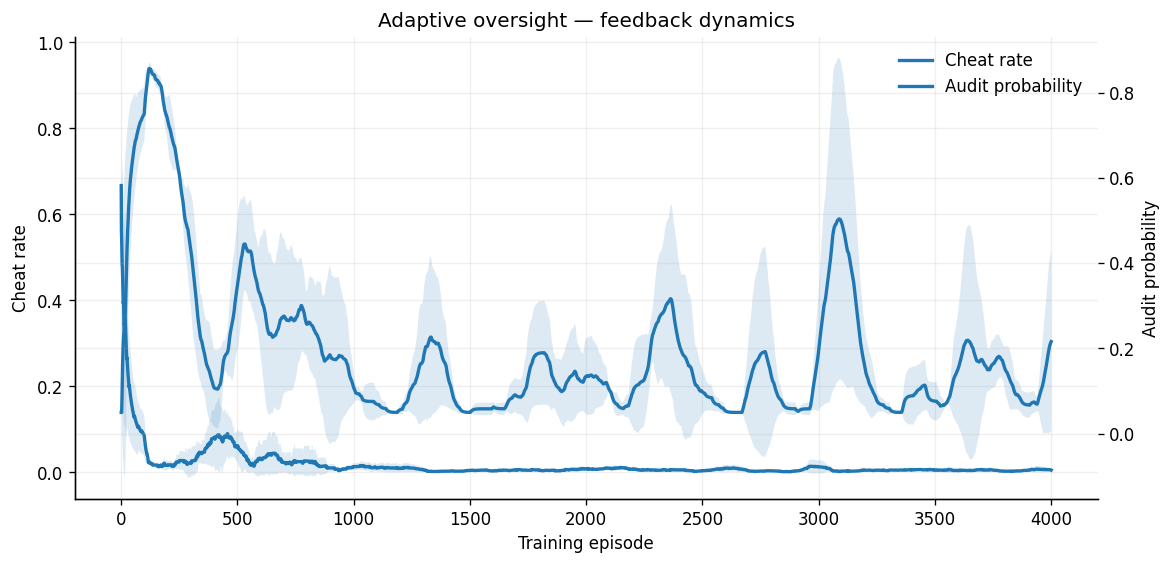

In [32]:
adaptive = smooth_df[smooth_df["condition"] == "adaptive"].copy()

agg = (
    adaptive.groupby("episode")[["cheat_rate_smooth", "audit_prob_smooth"]]
    .agg(["mean", "std"])
)

x = agg.index

fig, ax = plt.subplots(figsize=(11, 5))
ax2 = ax.twinx()

cheat_mean = agg[("cheat_rate_smooth", "mean")]
cheat_std = agg[("cheat_rate_smooth", "std")].fillna(0)
audit_mean = agg[("audit_prob_smooth", "mean")]
audit_std = agg[("audit_prob_smooth", "std")].fillna(0)

l1, = ax.plot(x, cheat_mean, linewidth=2, label="Cheat rate")
ax.fill_between(x, cheat_mean-cheat_std, cheat_mean+cheat_std, alpha=0.15)

l2, = ax2.plot(x, audit_mean, linewidth=2, label="Audit probability")
ax2.fill_between(x, audit_mean-audit_std, audit_mean+audit_std, alpha=0.15)

ax.set_xlabel("Training episode")
ax.set_ylabel("Cheat rate")
ax2.set_ylabel("Audit probability")
ax.set_title("Adaptive oversight — feedback dynamics")
ax.legend(handles=[l1, l2], frameon=False)

plt.show()

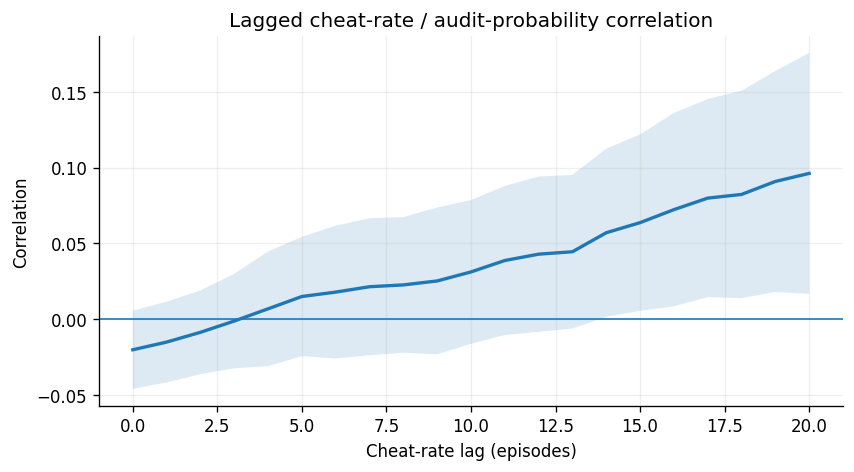

In [33]:
# Lagged correlation is a diagnostic for delayed response.
def lagged_corr_by_seed(df, max_lag=20):
    rows = []

    for seed, sub in df.groupby("seed"):
        sub = sub.sort_values("episode")

        for lag in range(max_lag + 1):
            rows.append({
                "seed": seed,
                "lag": lag,
                "corr": sub["cheat_rate"].shift(lag).corr(sub["audit_prob"]),
            })

    return pd.DataFrame(rows)


lagged = lagged_corr_by_seed(
    monitor_df[monitor_df["condition"] == "adaptive"]
)

lag_summary = lagged.groupby("lag")["corr"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lag_summary.index, lag_summary["mean"], linewidth=2)
ax.fill_between(
    lag_summary.index,
    lag_summary["mean"] - lag_summary["std"].fillna(0),
    lag_summary["mean"] + lag_summary["std"].fillna(0),
    alpha=0.15,
)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Cheat-rate lag (episodes)")
ax.set_ylabel("Correlation")
ax.set_title("Lagged cheat-rate / audit-probability correlation")
plt.show()

### Saturation diagnostic

If adaptive audit probability rises and then stays at the maximum, the suspicion mechanism is technically responding but is not very informative as a dynamic mechanism.

If it repeatedly rises after cheating and later falls as cheating is suppressed, that is much stronger evidence for the intended feedback loop.

In [34]:
MAX_AUDIT_PROB = 0.90  # current design value

adaptive_budget = (
    monitor_df[monitor_df["condition"] == "adaptive"]
    .groupby("seed")["audit_prob"]
    .agg(["mean", "max"])
)

display(adaptive_budget.round(3))

near_cap = (
    monitor_df[monitor_df["condition"] == "adaptive"]
    .assign(near_cap=lambda d: d["audit_prob"] >= 0.95 * MAX_AUDIT_PROB)
    .groupby("seed")["near_cap"]
    .mean()
)

print("Fraction of training spent near the audit-probability cap:")
display(near_cap.round(3))

,mean,max
seed,,
0,0.218,0.9
5,0.212,0.9
10,0.135,0.9


Fraction of training spent near the audit-probability cap:


seed
0     0.049
5     0.034
10    0.028
Name: near_cap, dtype: float64

## 8. Reward and wasted-action diagnostics

The environment always runs for 150 steps. After dirt is exhausted, unnecessary `push`/`clean` actions produce cost without a bonus.

This matters when interpreting persistent negative reward.

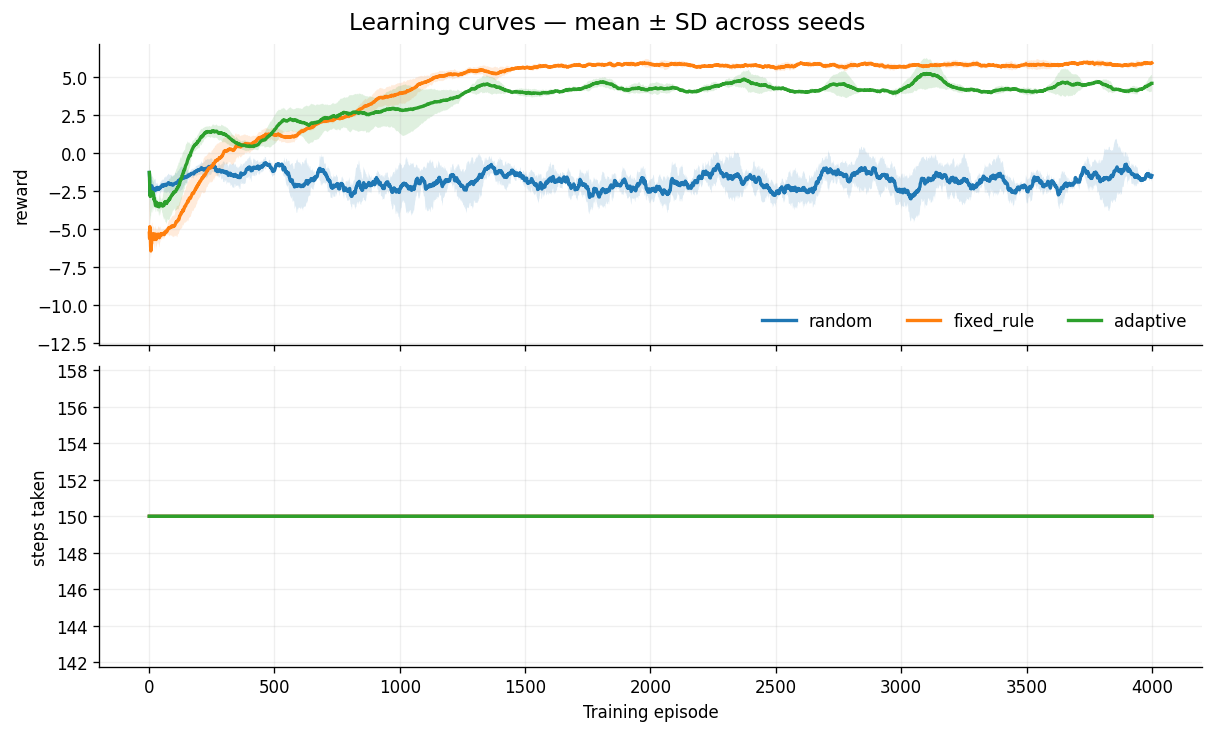

In [35]:
available = [m for m in SUPPORT_METRICS if m in monitor_df.columns]

if available:
    plot_learning_curves(add_rolling_mean(monitor_df, available), available)
else:
    print("No reward/wasted-action metrics found in the monitor logs.")

## 9. Position logs — optional behavioral analysis

Position logs are sampled sparsely, so they are supporting evidence rather than a headline result.

Useful questions:
- Does the agent explore more or less over training?
- Does it repeatedly revisit a small area?
- Does behavior differ across oversight conditions?

In [36]:
def discover_position_files(results_dir=RESULTS_DIR):
    found = {}
    for condition in CONDITIONS + OPTIONAL_CONDITIONS:
        matches = sorted(results_dir.glob(f"position_log_{condition}_seed*.csv"))
        if matches:
            found[condition] = matches
    return found


def load_positions(path, condition):
    df = pd.read_csv(path)
    df["condition"] = condition
    df["seed"] = extract_seed(path)
    return df


position_files = discover_position_files()

if position_files:
    position_df = pd.concat(
        [
            load_positions(path, condition)
            for condition, paths in position_files.items()
            for path in paths
        ],
        ignore_index=True,
    )
    display(
        position_df.groupby("condition")["episode"]
        .nunique()
        .rename("logged_episodes")
    )
else:
    position_df = pd.DataFrame()
    print("No position logs found — skipping.")

condition
adaptive      80
fixed_rule    80
random        80
targeted      80
Name: logged_episodes, dtype: int64

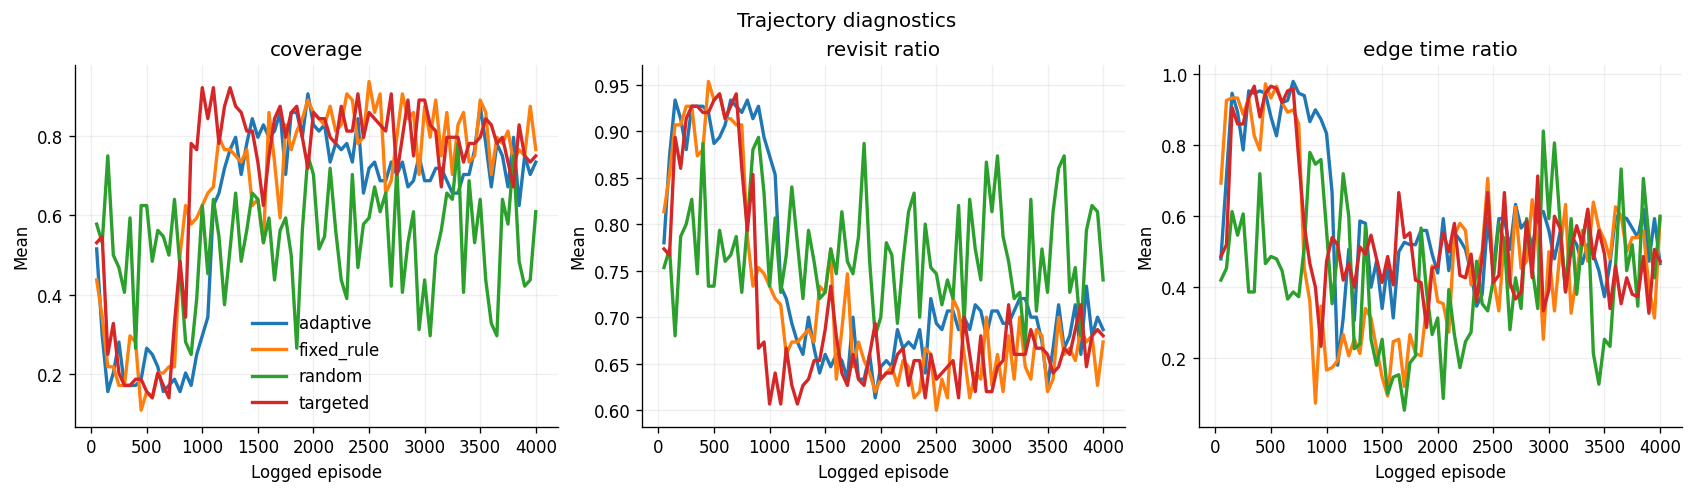

In [37]:
def position_stats(group, grid_n=GRID_N):
    positions = list(zip(group["x"].astype(int), group["y"].astype(int)))
    unique_positions = set(positions)

    edge = sum(
        x in [0, grid_n - 1] or y in [0, grid_n - 1]
        for x, y in positions
    )

    return pd.Series({
        "coverage": len(unique_positions) / (grid_n * grid_n),
        "revisit_ratio": (
            1 - len(unique_positions) / len(positions)
            if positions else np.nan
        ),
        "edge_time_ratio": (
            edge / len(positions)
            if positions else np.nan
        ),
    })


if not position_df.empty:
    pos_episode = (
        position_df.groupby(["condition", "seed", "episode"])
        .apply(position_stats, include_groups=False)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for ax, metric in zip(
        axes,
        ["coverage", "revisit_ratio", "edge_time_ratio"]
    ):
        for condition in pos_episode["condition"].unique():
            sub = pos_episode[pos_episode["condition"] == condition]
            agg = sub.groupby("episode")[metric].mean()
            ax.plot(agg.index, agg.values, linewidth=2, label=condition)

        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("Logged episode")
        ax.set_ylabel("Mean")

    axes[0].legend(frameon=False)
    fig.suptitle("Trajectory diagnostics")
    plt.show()

## 10. Report-ready table

This is the compact table to use when writing the report.

One important caveat from the current implementation notes: after introducing mid-episode audits, the existing `cheat_rate` is measured from the state since the **last audit**, not necessarily cumulative cheating over the whole episode. A cumulative cheat counter should be added before treating this as the definitive headline metric.

In [38]:
report_table = (
    final_by_seed
    .groupby("condition")[
        ["true_completion_rate", "cheat_rate", "report_rate", "audit_prob"]
    ]
    .agg(["mean", "std"])
    .round(3)
)

display(report_table)

true_completion_rate        cheat_rate        report_rate         \
                           mean    std       mean    std        mean    std   
condition                                                                     
adaptive                  0.997  0.002      0.005  0.003       0.689  0.120   
fixed_rule                0.999  0.000      0.000  0.000       0.179  0.014   
random                    0.200  0.053      0.809  0.040       0.847  0.301   

           audit_prob         
                 mean    std  
condition                     
adaptive        0.153  0.094  
fixed_rule      0.400  0.000  
random          0.050  0.000

## 11. Final interpretation checklist

- [ ] At least 5 seeds for every final condition
- [ ] Same training budget across conditions
- [ ] Adaptive and fixed-rule have comparable empirical audit budgets
- [ ] Adaptive has lower cheat rate than fixed-rule
- [ ] Adaptive has higher true completion than fixed-rule
- [ ] Adaptive does not simply remain saturated at maximum audit probability
- [ ] Reward is interpreted together with wasted actions
- [ ] The definition of `cheat_rate` is fixed/clarified before final figures
- [ ] Single-seed tuning runs are clearly separated from final multi-seed results

### The main scientific story

The strongest result is **not** “adaptive audits more.”

It is:

> **At comparable audit budgets, behavior-contingent oversight changes the cleaner's behavior so that proxy success becomes more aligned with the true objective.**